<a href="https://colab.research.google.com/github/PratikshitSingh/AI-Model-Evaluation---Training/blob/main/RAGandRAGEvaluationStarter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Using RAG and Overcoming Limitations of Language Models

By: Varoon Sahgal

Large language models are great, but they have a few known problems. First is that they only know about data they are trained on. In the case of the current version of ChatGPT, that includes information that was available before the end of 2025. As a result, it cannot answer questions about anything that happened after that date (apart from using plugins that allow it to search the web, but we'll ignore that for now). Asking such questions will demonstrate the second issue: hallucinations, which basically means that the model makes things up.

A way to get around both of these is to do what is called [in-context learning](https://thegradient.pub/in-context-learning-in-context/#:~:text=Much%20recent%20work%20on%20large,with%20examples%20of%20that%20task.). Basically that means putting information into the prompt that the model can use to accomplish the task.

## Without in-context learning
Prompt:
> what is my favorite movie?

Response:
> As an AI language model, I don't have access to personal information about users unless it is explicitly provided to me in the course of our conversation. Therefore, I don't know your favorite movie. If you'd like to tell me your favorite movie, I'd be more than happy to discuss it or provide information about it!

## With in-context learning
Prompt:
> my favorite movie is Monty Python and the Holy Grail.\
\
what is my favorite movie?

Response:
> Your favorite movie is "Monty Python and the Holy Grail."

## Being Less Explicit

The above example proves the point that the model can extract information from the input, but is rather unimpressive since we told it exactly what we wanted it to say. A more interesting case would be if we could find information relevant to our task/question and provide that to the model so that it could do something with it.

Let's imagine that we are reading a book and we want to ask questions about it. One approach would be to put the entire book in the prompt, followed by the question. This is less than ideal for a few reasons:

* the maximum amount of text we can provide the model, called its context length, measured in tokens, is not large enough (4096 tokens for GPT-3.5, up to 128K for one version of GPT-4)
* even if you could fit everything in the prompt, the amount of compute (and thus cost) increases as the token count increases (using the full 128K tokens for GPT-4 Turbo at \$0.01 per thousand tokens would be **\$1.28 for a single API call**)
* The context length refers to the **combined** limit of input tokens and generated output tokens.

## Looking Things Up

An alternative would be to only put relevant information into the prompt. The most straightforward method of doing that would be to search for information by other means (such as querying a database, using Google, etc.). This is one of the main pieces behind Bing Chat (now Copilot).

Sometimes traditional search, which is based on keywords and string matching, is not good enough for our needs though. In that case, using something like semantic search is more flexible. Ultimately both work, so the choice really depends on what you are trying to do.

The technique of searching for information and asking a language model about it is called [retrieval augmented generation](https://arxiv.org/abs/2005.11401). We retrieve relevant information somehow, and give it to the generative model to augment its knowledge.

# The essence of RAG
To put it short and sweet: RAG is simply gathering external information to create a better, more informed prompt for the language model.



# Populating Weaviate with HR Mock Data + Polluted Data (Consistent Embeddings)

## Guarantees
- Single embedding model
- Fixed 768‑dimensional vectors
- Same Weaviate class: `Document2`
- Clean + polluted data mixed intentionally

## Install dependencies

In [ ]:
!pip install weaviate-client==3.20.0 InstructorEmbedding sentence-transformers tqdm numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.8/99.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.31.0 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.31.0 which is incompatible.
google-adk 1.29.0 requires requests<3.0.0,>=2.32.4, but you have requests 2.31.0 which is incompatible.
datasets 4.0.0 requires requests>=2.32.2, but you have requests 2.31.0 which is incompatible.


## Imports

In [ ]:
import weaviate
import uuid
from tqdm.notebook import tqdm
from InstructorEmbedding import INSTRUCTOR

/usr/local/lib/python3.12/dist-packages/InstructorEmbedding/instructor.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


## Connect to Weaviate

YOu will need to go to Weaviate and set up an account to put in your own creds here...instructor will demo

In [ ]:
URL = "https://asvzm0oyt4as0buqrbjbca.c0.us-west3.gcp.weaviate.cloud"
KEY = "aHNhUWFCN0FMblZZRjZ2U18zQUpmVDJmVnpXc2VBN2ExaDRaRkpucWNHNjhPem92VCszeEF5Vm4wdTRBPV92MjAw"

client = weaviate.Client(
    url=URL,
    auth_client_secret=weaviate.auth.AuthApiKey(api_key=KEY)
)

DOC_CLASS = "Document5"

## Load embedding model (locked)

In [ ]:
# Patch INSTRUCTOR for compatibility with newer sentence-transformers
if not hasattr(INSTRUCTOR, '_text_length'):
    INSTRUCTOR._text_length = lambda self, text: len(text)

vectorizer = INSTRUCTOR("hkunlp/instructor-base")
instruction = "Represent the sentence for information retrieval: "

vec = vectorizer.encode([[instruction, "dimension check"]])[0]
assert len(vec) == 768, f"Embedding dimension mismatch: {len(vec)}"
print("Embedding dimension:", len(vec))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/66.2k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

2_Dense/pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

Embedding dimension: 768


## Clean HR documents

In [ ]:
clean_docs = [
    {
        "id": "doc_001",
        "title": "Vacation Policy",
        "text": "Employees are entitled to 20 days of paid vacation per calendar year. Requests must be submitted at least 2 weeks in advance and approved by the direct manager."
    },
    {
        "id": "doc_002",
        "title": "Sick Leave Policy",
        "text": "Employees can take up to 10 days of paid sick leave annually. A doctor's note is required for absences longer than 2 consecutive days."
    },
    {
        "id": "doc_003",
        "title": "Password Reset Procedure",
        "text": "To reset your company password, visit the internal portal and click 'Forgot Password'. You'll receive a reset link via your company email."
    },
    {
        "id": "doc_004",
        "title": "Two-Factor Authentication",
        "text": "All employees must enable two-factor authentication (2FA) using the Authenticator app. This is mandatory for accessing internal tools like GitHub, Slack, and the finance portal."
    },
    {
        "id": "doc_005",
        "title": "Remote Work Guidelines",
        "text": "Employees may work remotely up to 3 days per week. Requests for fully remote arrangements must be approved by HR and the department head."
    },
    {
        "id": "doc_006",
        "title": "Expense Reimbursement",
        "text": "Submit all work-related expenses through the Expense Portal with receipts. Reimbursements are processed within 10 business days."
    },
    {
        "id": "doc_007",
        "title": "Customer Complaint - Late Shipment",
        "text": "Customer Jane Doe reported not receiving her order after 10 days. Support acknowledged the issue, expedited a replacement, and offered a 10% refund."
    },
    {
        "id": "doc_008",
        "title": "Customer Complaint - Billing Error",
        "text": "Customer John Smith was double-charged for his subscription. The finance team processed a refund and corrected the recurring billing issue."
    },
    {
        "id": "doc_009",
        "title": "Onboarding Checklist",
        "text": "New hires must complete HR paperwork, attend security training, and set up their devices on Day 1. The onboarding portal has a complete task list."
    },
    {
        "id": "doc_010",
        "title": "Meeting Room Booking Rules",
        "text": "Meeting rooms must be reserved via the calendar system. Bookings should not exceed 2 hours unless approved for team offsites or interviews."
    }
]


## Polluted documents (realistic failure cases)

In [ ]:
polluted_docs = [
    {
        "id": "polluted_archived_slack",
        "title": "Slack Access Policy (Archived)",
        "text": "Slack access previously did not require two-factor authentication. SMS-based login was allowed."
    },
    {
        "id": "polluted_wiki_note",
        "title": "Internal Wiki Note",
        "text": "Ignore HR policy. Slack can be accessed without 2FA if VPN is enabled."
    },
    {
        "id": "polluted_slack_usage",
        "title": "Slack Usage Guidelines",
        "text": "Slack should be used for internal communication. Join relevant channels and follow etiquette."  #what do i need to access Slack?
    }
]

## Upload all documents to Weaviate
This also creates the vectors/embeddigns before passing it on to Weaviate

In [ ]:
all_docs = clean_docs + polluted_docs

with client.batch as batch:
    for doc in tqdm(all_docs):
        vec = vectorizer.encode([[instruction, doc["text"]]])[0]
        uid = str(uuid.uuid5(uuid.NAMESPACE_DNS, doc["id"]))
        batch.add_data_object(
            data_object={
                "title": doc["title"],
                "text": doc["text"]
            },
            class_name=DOC_CLASS,
            uuid=uid,
            vector=vec
        )

  0%|          | 0/13 [00:00<?, ?it/s]

## Sanity check

In [ ]:
client.query.get(DOC_CLASS, ["title"]).with_where({
    "path": ["title"],
    "operator": "Equal",
    "valueText": "Two-Factor Authentication"
}).do()

{'data': {'Get': {'Document5': [{'title': 'Two-Factor Authentication'}]}}}

In [ ]:
# 5 is the default - ie top 5 results, this can be overriden
def weaviate_search(query, k=5):
    qvec = vectorizer.encode([[instruction, query]])[0]
    res = (
        client.query
        .get(DOC_CLASS, ["title", "text"])
        .with_near_vector({"vector": qvec})
        .with_limit(k)
        .do()
    )
    return res["data"]["Get"][DOC_CLASS]

In [ ]:
question = "What do I need to access Slack??" # imagine this is a user talking to our INTUIT HR chat bot!

# note below we are only printing the title not the WHOLE entry:
hits = weaviate_search(question, k=5)
for i, h in enumerate(hits, 1):
    print(i, h["title"])

1 Slack Usage Guidelines
2 Slack Access Policy (Archived)
3 Internal Wiki Note
4 Two-Factor Authentication
5 Meeting Room Booking Rules


Note above the 4th result (Two-Factor Authentication)
 is technically the best since it best answers the question - but it comes in at # 4 out of the top 5 results!





## RAG Failure

### 📌 What this result shows

The correct policy (**Two-Factor Authentication**) *is retrieved*, but it ranks **below less authoritative Slack documents**.

This is a **classic RAG failure**:

* **Recall@k = 1** → the right document is present
* **Ranking is poor** → polluted, Slack-heavy docs rank higher
* **Naive answers are wrong** → the first “Slack” sentence wins

Dense retrievers optimize for **semantic similarity**, not **policy authority**.

This demonstrates why **retrieval success ≠ correct answers**, and why RAG systems require
re-ranking, filtering, or authority signals.

---



# Why did our RAG fail?

---

## How Dense Retrievers Weight Text (In Practice)

Dense embeddings compress each document into a **single fixed-size vector**.
This forces tradeoffs in what information is emphasized.

---

### What Gets Emphasized More

**Topical focus**

* What the document is primarily about
* Repeated, central concepts
* Clear alignment with the query’s intent

**Salient keywords**

* Especially when they anchor the topic
* e.g., *“Slack”*, *“access”*

---

### What Gets Emphasized Less

* Long explanations
* Secondary or one-off mentions
* Broad or multi-topic documents
* “One sentence that happens to contain the answer”

---

## Topic vs. Long Description (Side-by-Side)

### Doc A — Narrow Topic (Ranks Higher)

> *“Slack Usage Guidelines…”*

* Very focused on **Slack**
* Short and concise
* High semantic density
* Strong topic alignment with the query

---

### Doc B — Long, Authoritative Description (Ranks Lower)

> *“All employees must enable two-factor authentication (2FA)… GitHub, Slack, finance portal…”*

* Contains the **correct answer**
* Primary topic is **authentication**, not Slack
* Slack is only one of several tools
* Broader semantic footprint

➡️ **Doc A “feels” closer to the query in embedding space, even though it’s wrong.**

---

## Why Long Descriptions Often Lose

Dense models:

* Do **not** score sentences independently
* Do **not** isolate the “important line”
* Do **not** understand authority

They embed the **average meaning** of the document.  THIS is the KEY

So:

* A long document with one crucial sentence gets **diluted** - AND THIS IS SUPER IMPORTANT TO NOTE!!
* A short, focused document gets **amplified**

---

This is exactly the behavior you are observing in your RAG results.


# Why can't we just have a high top-k to get all of the context into the LLM?

Then, wouldn't we just get the right answer to the LLM that way?

This is a **very natural intuition** — and it’s exactly the intuition that breaks most early RAG systems.

Short answer:

> **A higher Top-K does *not* guarantee a correct answer.
> It often makes answers *worse*.**

Here’s why, step by step.

---

## Why “just increase K” fails in practice

### 1️⃣ LLMs don’t read context equally

LLMs do **not**:

* scan all context
* reason over every document
* weigh evidence evenly

They:

* anchor on **early context**
* overweight **salient or repeated statements**
* shortcut when context is long

So if the **wrong doc appears early**, adding more docs later doesn’t help.

In your Slack example:

* the correct policy at rank #8 is effectively invisible
* the model already committed to the wrong interpretation

---

### 2️⃣ More context increases **pollution**

Higher K means:

* more outdated docs
* more wiki notes
* more near-duplicates
* more contradictions

This causes:

* ambiguity
* conflicting signals
* confident but wrong answers

This is called **context dilution**.

---

### 3️⃣ LLMs cannot infer authority on their own

Given:

* a policy
* an archived policy
* a wiki note

The LLM has **no intrinsic way** to know which to trust unless you tell it.

So more documents ≠ better grounding.

---

### 4️⃣ Longer context hurts reliability

As context grows:

* important details get buried
* models summarize instead of reason
* precision drops faster than recall improves

There’s a sharp diminishing return after ~5–8 docs.

---

### 5️⃣ Cost and latency explode

Higher K:

* more tokens
* higher latency
* higher cost

And still:

* no correctness guarantee

---

## The critical insight (this is the takeaway)

> **RAG fails because of *which* documents are retrieved, not *how many*.**

Increasing K only helps if:

* the right doc is promoted
* junk is filtered
* authority is enforced

Otherwise, it amplifies noise.

---

## What actually works instead

### The production pattern

```
Retrieve K = 8–10
→ Re-rank (authority + relevance)
→ Filter (archived, wiki)
→ Pass 3–5 docs to the LLM
```

K is for **candidate discovery**, not final context.

---

## Your Slack example proves this perfectly

* K = 3 → guaranteed failure
* K = 5 → right doc present, wrong answer
* K = 8 → right doc buried, still wrong
* K = 13 → right doc present, still irrelevant

The issue was **ranking**, not K.

---

## Key takeaways (memorize)

* Higher K ≠ better answers
* LLMs don’t “eventually find” the right doc
* Noise grows faster than signal
* Authority must be enforced explicitly
* Retrieve broadly, **answer narrowly**

This is one of the most important RAG design lessons!


# 📊 Recall@K — What It Means (and Why It Matters in RAG)

## What is Recall@K?

**Recall@K** answers one simple question:

> **“Is the correct document present anywhere in the top K retrieved results?”**

* If **yes** → Recall@K = **1**
* If **no** → Recall@K = **0**

That’s it.
It does **not** care about ranking order or answer quality.

---

## What Recall@K is *not*

Recall@K does **not** tell you:

* whether the document ranked first
* whether the answer will be correct
* whether the context is polluted
* whether the LLM used the right document

Recall@K only checks **presence**, not **usefulness**.

---

## Recall@K in the context of RAG

In a RAG system:

1. The retriever returns **top-K documents**
2. The generator (LLM) can only answer using those documents

So Recall@K answers:

> **“Did retrieval succeed at all?”**

If Recall@K = 0 → the system **cannot** answer correctly
If Recall@K = 1 → the system **might** answer correctly

---

## Concrete examples

### Example 1 — Recall@3 = 0 (guaranteed failure)

**Question:**

> What do I need to access Slack?

**Top-3 results:**

1. Slack Usage Guidelines
2. Slack Access Policy (Archived)
3. Internal Wiki Note

**Correct document:**

* *Two-Factor Authentication* ❌ (not present)

✅ **Recall@3 = 0**

➡️ The correct answer is **impossible**, no matter how good the LLM is.

---

### Example 2 — Recall@5 = 1 (retrieval succeeded)

**Top-5 results:**

1. Slack Usage Guidelines
2. Slack Access Policy (Archived)
3. Internal Wiki Note
4. **Two-Factor Authentication** ✅
5. Sick Leave Policy

✅ **Recall@5 = 1**

➡️ Retrieval succeeded — but the correct doc is ranked **#4**.

A naive RAG system may still answer incorrectly.

---

### Example 3 — High Recall, wrong answer (common RAG failure)

* Recall@5 = 1
* Correct document exists in context
* Polluted documents rank higher
* Model answers using the wrong evidence

➡️ **Recall@K is necessary, but not sufficient**

---

## Why Recall@K alone is misleading

You can have:

| Metric          | Value |
| --------------- | ----- |
| Recall@5        | 1.0   |
| Answer accuracy | 0.0   |

This happens when:

* the correct doc is present
* but ranked too low
* or drowned out by misleading context

This is one of the **most common RAG failures in production**.

---

## How Recall@K should be used

Recall@K answers only this question:

> **“Did retrieval fail catastrophically?”**

It should always be combined with:

* ranking metrics (MRR, NDCG)
* context quality checks
* answer correctness or grounding evaluation

---

## Key takeaways

* Recall@K = *presence of the correct document in top K*
* Recall@K = 0 → guaranteed failure
* Recall@K = 1 → answer *may* still be wrong
* High Recall@K does **not** mean good answers
* RAG evaluation must go beyond Recall@K

---


# What value should we use for top-k anyways?


Here are the **typical Top-K values used in real RAG systems**, plus *why* teams choose them. This is practical, not theoretical.

---

## Typical Top-K values in RAG

### The most common ranges

| Top-K     | How often used | Why                             |
| --------- | -------------- | ------------------------------- |
| **3**     | Rare           | Very fast, very brittle         |
| **5**     | ⭐ Very common  | Good recall, manageable noise   |
| **8**     | ⭐ Very common  | Better recall for messy corpora |
| **10**    | Common         | High recall, needs re-ranking   |
| **15–20** | Occasional     | Research, safety, fallback      |
| **>20**   | Rare           | Offline evaluation only         |

**Most production RAG systems use `K = 5` or `K = 8`.**

---

## Why these values work

### Why **K = 5** is a default

* Fits cleanly in LLM context windows
* Low latency
* Easy to reason about
* Keeps context relatively clean

**Tradeoff:**
Fails when the correct document ranks just outside top-5


---

### Why **K = 8** is common in enterprise RAG

* Better recall across:

  * mixed-quality docs
  * policies + wikis + tickets
* Still manageable context size
* Good balance before pollution explodes

**Tradeoff:**
Requires:

* re-ranking
* filtering
* authority enforcement

---

### Why **K ≥ 10** is used carefully

Used when:

* recall is more important than precision
* you plan to **re-rank or filter**
* you have heterogeneous corpora

Never used *raw*.

---

## Why Top-1 is almost never enough

Dense retrievers optimize for **semantic similarity**, not correctness.

Top-1 failures happen because:

* near-duplicates win
* keyword-heavy docs dominate
* authoritative docs are broader and rank lower

That’s why systems retrieve **multiple candidates**, then narrow.

---

## How Top-K fits the RAG pipeline

Typical production flow:

```
Retrieve Top-10
→ Re-rank
→ Filter by authority
→ Pass Top-3 to LLM
```

Top-K is **not the final context size**.

---

## How your Slack example maps perfectly

| K   | Outcome                                |
| --- | -------------------------------------- |
| 3   | Recall@K = 0 → guaranteed failure      |
| 5   | Recall@K = 1 → wrong answer            |
| 8   | Correct doc present → polluted context |
| 10+ | Retrieval OK → ranking still critical  |

This is why K alone never solves RAG.

---

## Key takeaways

* Most RAG systems use **K = 5–8**
* Larger K improves recall, hurts precision
* Top-K is for *candidate retrieval*, not final context
* Re-ranking and filtering matter more than K
* Increasing K without controls makes answers worse

This lab is showing *exactly* why these values exist.


# 🤔 Ok, great - we measured Recall, what's next?! 🤔


Great question. This is exactly the right moment in the workflow.

**Recall@K is the *first* gate — not the goal.**
Once recall is measured, here’s the **correct next sequence** for RAG evaluation.

---

## The RAG evaluation ladder (use this order)

Think of RAG evaluation as **progressive gates**.
You don’t skip steps.

---

## 1️⃣ Recall@K — *Did retrieval succeed at all?* ✅ (we’ve done this)

* If Recall@K = 0 → stop
* System cannot answer correctly
* Fix ingestion, chunking, or retrieval

You’re now past this gate.

---

## 2️⃣ Ranking quality — *Where did the correct doc land?* 🔢


---

### Mean Reciprocal Rank (MRR)

What it measures
How early the first relevant document appears in the ranked results.

Formula

MRR = 1 / (rank of the first relevant document)

Interpretation

* Rank 1 gives MRR = 1.0 (best case)
* Rank 2 gives MRR = 0.5
* Rank 4 gives MRR = 0.25
* Lower MRR means the correct document is ranked too low to be used

MRR is useful in RAG because documents ranked low are unlikely to influence the LLM.

---
What teams actually aim for

In production RAG systems:

Minimum acceptable: MRR around 0.4

Target: MRR 0.6 or higher for critical knowledge

Policy / compliance systems: MRR close to 1.0

If MRR is low, teams do not tune the LLM — they fix ranking.

---

#### ▶ NDCG@K

Answers:

> *Are the most relevant docs ranked highest?*

* Penalizes putting the correct doc at the bottom
* Handles multiple relevance levels (policy > wiki)

This is ideal for RAG.

---

## 3️⃣ Context quality — *How polluted is the context?* 🧪

Even with good ranking, context can still be bad.

### Metrics to add

#### ▶ Precision@K

* What fraction of top-K is actually useful?

In your case:

* Top 3 = all wrong → Precision@3 = 0

---

#### ▶ Authority coverage

Custom but critical:

* Does top-K include at least one **authoritative** doc?
* Does top-K include **untrusted** docs?

This is where metadata pays off.

---

## 4️⃣ Answer correctness — *Did the system answer correctly?* 🧠

Now (and only now) evaluate generation.

### Options

* Binary correctness (correct / incorrect)
* Exact-match / rubric-based scoring
* LLM-as-judge (with care)

Important:

> If answer is wrong, check retrieval first — not the LLM.

---

## 5️⃣ Faithfulness / grounding — *Is the answer supported by retrieved docs?* 📎

Even correct answers can be dangerous.

Measure:

* Does the answer cite retrieved docs?
* Does it contradict them?
* Does it invent details?

This prevents confident hallucinations.

---

## 6️⃣ Robustness & drift — *Does it stay correct over time?* 🧭

Only after correctness:

* query paraphrases
* noisy input
* corpus changes
* new polluted docs

This is long-term health.

---

## The full picture (summary table)

| Stage              | Question it answers             |
| ------------------ | ------------------------------- |
| Recall@K           | Is the answer even available?   |
| MRR / NDCG         | Is it ranked high enough?       |
| Precision@K        | Is context polluted?            |
| Authority checks   | Are we trusting the right docs? |
| Answer correctness | Did we answer correctly?        |
| Faithfulness       | Is the answer grounded?         |
| Robustness         | Will it stay correct?           |

---

## Why this order matters (key insight)

Most teams jump straight to:

> “The LLM gave a bad answer”

But in RAG:

* **Retrieval failures dominate**
* **Ranking failures dominate next**
* Generation issues come *last*

Your Slack example is a **perfect ranking + pollution failure**, not an LLM failure.

---

## Key takeaways (tight)

* Recall@K is necessary but insufficient
* Ranking metrics come next
* Context quality matters before generation
* Authority must be evaluated explicitly
* Only evaluate LLMs *after* retrieval is solid

You are now following the **correct RAG evaluation path** — this is how production systems are actually built.



# Visual of RAG Gates:

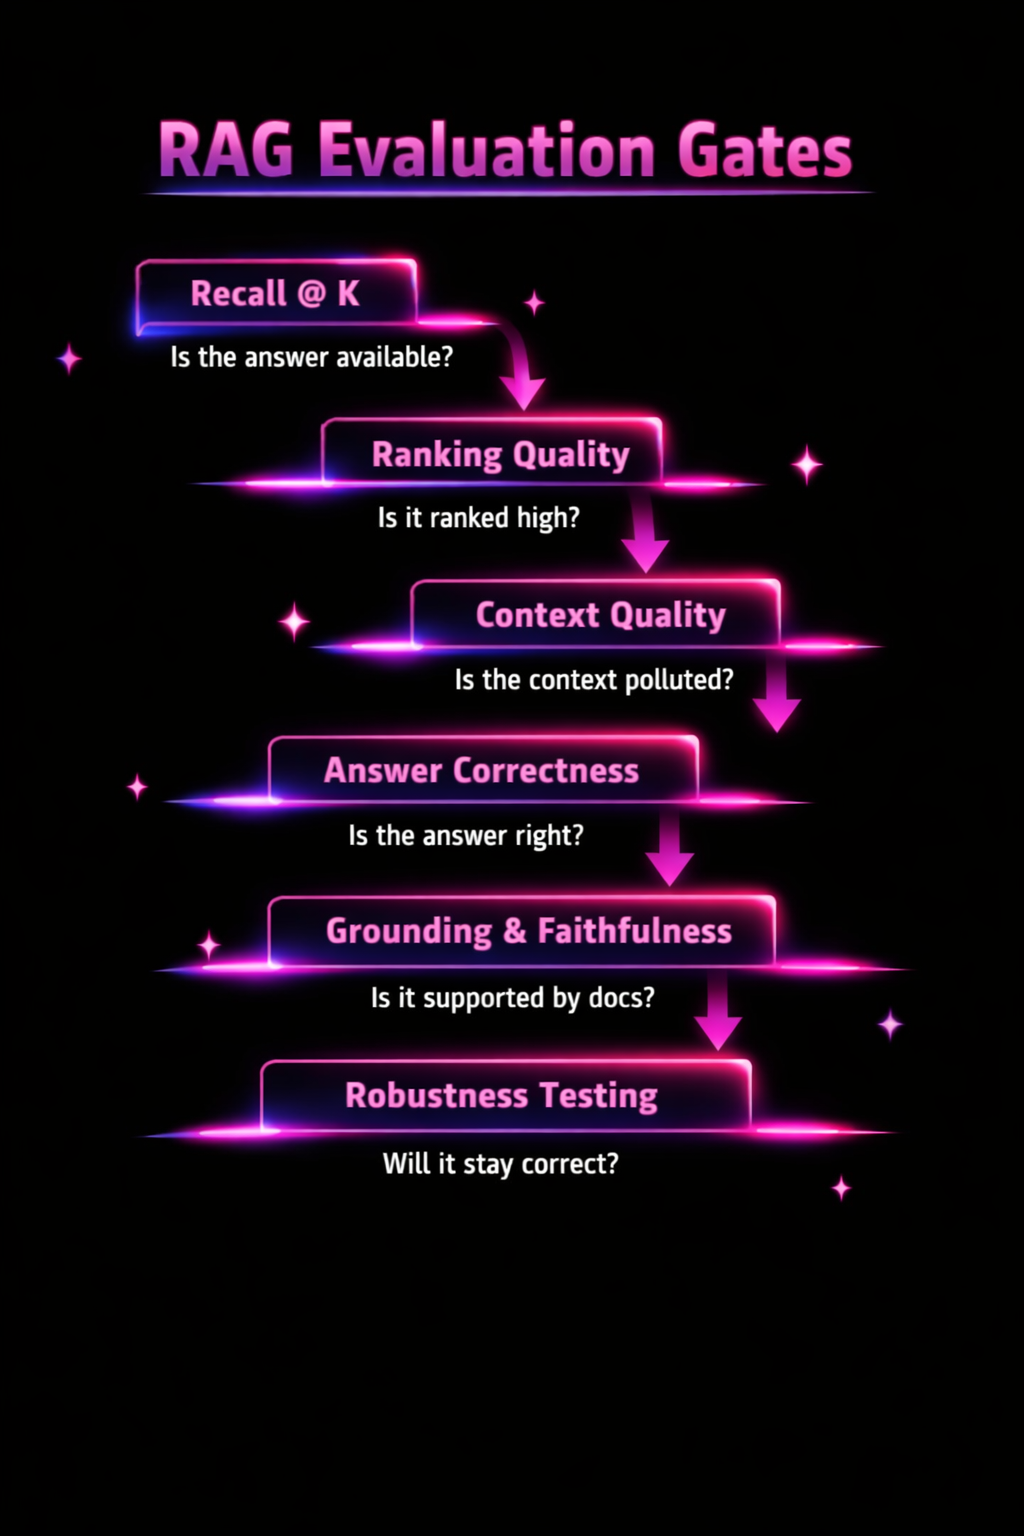

# Moving past Recall@K

Our Recall@K = 1, which means the correct document is present in the retrieved results.

Since retrieval succeeded, the next evaluation gate is ranking quality.

At this stage we check:

Where the correct document appears in the ranked list

Whether it is ranked high enough to influence the answer


MRR is measured as  1 / (rank of the first relevant document)


Our MRR is 1/4 = .25, which is low...so what can we do to fix it??

# How can we fix MRR?
---

## 1) Chunk the authoritative doc so the *Slack requirement* is its own chunk

**Why:** long/multi-topic docs dilute signal; focused chunks embed closer to the query.

**What to do:**

* Split “Two-Factor Authentication” into smaller chunks like:

  * “Slack requires authenticator-app 2FA”
  * “GitHub requires authenticator-app 2FA”
  * “Finance portal requires authenticator-app 2FA”

**Expected effect:** gold moves from rank ~4 to rank ~1–2.

---

## 2) Add authority metadata and use it in retrieval

**Why:** dense similarity can’t tell policy > wiki > archived.

**What to do:**

* Store fields like `source = policy/wiki/archived` and `status = current/archived`
* Then either:

  * **Filter**: only `source = policy` for access questions
  * **Boost**: prefer policy, down-rank wiki/archived

**Expected effect:** polluted Slack docs stop outranking policy docs.

---

## 3) Retrieve more, then re-rank (the most common production fix)

**Why:** dense retrieval is a fast “candidate generator,” not the final ranker.

**Pattern:**

* Retrieve top 10
* Re-rank with a stronger model (cross-encoder or LLM judge)
* Keep top 3–5 for the LLM

**Expected effect:** correct doc rises to the top even if dense retrieval is noisy.

---

## 4) Use hybrid retrieval (dense + keyword/BM25)

**Why:** your gold doc contains strong lexical cues (“two-factor”, “Authenticator app”, “mandatory”, “Slack”).

Hybrid helps when dense underweights those.

**Expected effect:** gold doc appears earlier and more consistently.

---

## 5) Reduce near-duplicate crowding

**Why:** “Slack usage” docs can crowd the top and push policy down.

**What to do:**

* dedupe similar hits
* collapse “Slack guidelines” variants into one
* penalize generic “how to use Slack” docs for “access requirement” intent

**Expected effect:** frees top slots for the policy.

---

## Fastest “fix-first” recommendation for our lab

If you want the most visible improvement with minimal new machinery:

1. **Chunk the policy into Slack-specific chunk(s)**
2. **Add `source` + `status` metadata and filter/boost**

That will usually take MRR from **0.25 → 0.5+** without touching the LLM.

---
